In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from transformers import BertTokenizer, BertModel
from transformers import get_linear_schedule_with_warmup
from torch.optim import AdamW

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import cohen_kappa_score

from scipy.stats import pearsonr

from tqdm import tqdm




In [2]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BATCH_SIZE = 8                  
EPOCHS = 10                      
PATIENCE = 3    
LEARNING_RATE = 2e-5
MAX_LENGTH = 384
RANDOM_SEED = 42
WARMUP_RATIO = 0.1

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(DEVICE)

cuda


In [ ]:
df = pd.read_csv(
    "../../../data/processing/task1_ielts_dataset.csv",
    engine="python",
    on_bad_lines="skip"
)

print("Total essays:", len(df))
df.head(10)


Total essays: 8548


,Topic,Question,Essay,Task_Achievement,Coherence_Cohesion,Lexical_Resource,Range_Accuracy,Overall,Overall_Clean,Examiner_Comment,length
0,Process Diagram,"Eating sweet foods produces acid in the mouth,...",The diagram illustrates a comparsion of differ...,NaN,NaN,NaN,NaN,5.0,NaN,NaN,249
1,Process Diagram,"Eating sweet foods produces acid in the mouth,...",The diagram illustrates the acid level in the ...,NaN,NaN,NaN,NaN,7.0,NaN,NaN,254
2,Line Graph,"Eating sweet foods produces acid in the mouth,...",The line graph depicts how a decay can appear ...,NaN,NaN,NaN,NaN,5.5,NaN,NaN,176
3,Table,Percentage of UK people who consumed daily rec...,The bar chart illustrates the rate of people w...,NaN,NaN,NaN,NaN,5.5,NaN,NaN,223
4,Table,Percentage of UK people who consumed daily rec...,The bar chart shed light on the proportions of...,NaN,NaN,NaN,NaN,7.5,NaN,NaN,213
5,Table,Percentage of UK people who consumed daily rec...,The bar graph compares the proportion of UK ci...,NaN,NaN,NaN,NaN,6.0,NaN,NaN,166
6,Table,Percentage of UK people who consumed daily rec...,The graph illustrates the percentage of fruit ...,NaN,NaN,NaN,NaN,5.5,NaN,NaN,175
7,Multiple Graphs,The Pie chart gives information about the coun...,The pie chart illustrates the percentage of Au...,NaN,NaN,NaN,NaN,6.5,NaN,NaN,174
8,Multiple Graphs,The Pie chart gives information about the coun...,The pie chart presents the information that th...,NaN,NaN,NaN,NaN,4.5,NaN,NaN,180
9,Multiple Graphs,The Pie chart gives information about the coun...,"There are many people lives in Australia,but t...",NaN,NaN,NaN,NaN,3.5,NaN,NaN,141


In [4]:
criteria_cols = ["Task_Achievement", "Coherence_Cohesion", "Lexical_Resource", "Range_Accuracy"]
df_task1 = df.copy()

df_task1["Overall_Clean"] = df_task1["Overall"].astype(float)


In [5]:
df_full = df_task1.dropna(subset=criteria_cols)
df_missing = df_task1[df_task1[criteria_cols].isna().any(axis=1)]
print("Full labeled:", len(df_full))
print("Missing:", len(df_missing))

Full labeled: 8063
Missing: 485


In [6]:
df[df["Task_Achievement"].isna()][
    ["Task_Achievement", "Coherence_Cohesion", 
     "Lexical_Resource", "Range_Accuracy"]
].isna().sum()

Task_Achievement      485
Coherence_Cohesion    485
Lexical_Resource      485
Range_Accuracy        485
dtype: int64

In [7]:
print("\nDESCRIBE FULL")
print(df_full[criteria_cols + ["Overall"]].describe())

print("\nDESCRIBE MISSING")
print(df_missing["Overall"].describe())

df_full["criteria_mean"] = df_full[criteria_cols].mean(axis=1)

print("\nCorrelation mean(criteria) vs Overall:")
print(pearsonr(df_full["criteria_mean"], df_full["Overall"]))

print("\nMAE consistency:")
print(mean_absolute_error(df_full["criteria_mean"], df_full["Overall"]))


DESCRIBE FULL
       Task_Achievement  Coherence_Cohesion  Lexical_Resource  Range_Accuracy  \
count       8063.000000         8063.000000       8063.000000     8063.000000   
mean           6.940469            6.384410          6.350490        6.255426   
std            1.263794            1.677158          1.550082        1.887601   
min            4.000000            3.000000          3.000000        3.000000   
25%            6.000000            5.000000          5.000000        4.500000   
50%            7.000000            6.500000          6.500000        6.000000   
75%            8.000000            8.000000          7.500000        8.000000   
max            9.000000            9.000000          9.000000        9.000000   

           Overall  
count  8063.000000  
mean      6.574166  
std       1.523126  
min       4.000000  
25%       5.000000  
50%       6.500000  
75%       8.000000  
max       9.000000  

DESCRIBE MISSING
count    485.000000
mean       6.321649
std     

In [8]:
def round_band(x):
    if pd.isna(x):
        return np.nan

    integer = int(x)
    decimal = x - integer

    if decimal < 0.25:
        return integer
    elif decimal < 0.75:   
        return integer + 0.5
    else:
        return integer + 1

In [9]:
mean_criteria = df_full[criteria_cols].mean(axis=1).apply(round_band)
diff = np.abs(mean_criteria - df_full["Overall_Clean"])

print("Mean diff:", diff.mean())
print("Within 0.5:", np.mean(diff <= 0.5))


Mean diff: 0.0
Within 0.5: 1.0


In [10]:
df_full["input_text"] = (
    "Overall Score: " + df_full["Overall_Clean"].astype(str) +
    " | Topic: " + df_full["Topic"].astype(str) +
    " | Word count: " + df_full["length"].astype(str) +
    " | Question: " + df_full["Question"].astype(str) +
    " [SEP] Essay: " + df_full["Essay"].astype(str)
)

In [11]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

encoded_inputs = tokenizer(
    df_full["input_text"].tolist(),
    padding=True,
    truncation=True,
    max_length=MAX_LENGTH,
    return_tensors="pt"
)

input_ids = encoded_inputs["input_ids"]
attention_masks = encoded_inputs["attention_mask"]

In [12]:
criteria = df_full[criteria_cols].values / 9.0
overall = df_full["Overall"].values / 9.0

criteria = torch.tensor(criteria, dtype=torch.float32)
overall = torch.tensor(overall, dtype=torch.float32)

In [13]:
indices = np.arange(len(df_full))

train_idx, temp_idx = train_test_split(
    indices, test_size=0.2, random_state=RANDOM_SEED # 80 20
)

val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.5, random_state=RANDOM_SEED# 10 10
)

print(len(train_idx), len(val_idx), len(test_idx))

6450 806 807


In [14]:
train_dataset = TensorDataset(
    input_ids[train_idx],
    attention_masks[train_idx],
    criteria[train_idx],
    overall[train_idx]
)

val_dataset = TensorDataset(
    input_ids[val_idx],
    attention_masks[val_idx],
    criteria[val_idx],
    overall[val_idx]
)

test_dataset = TensorDataset(
    input_ids[test_idx],
    attention_masks[test_idx],
    criteria[test_idx],
    overall[test_idx]
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

In [15]:
class BertMultiHead(nn.Module):

    def __init__(self):
        super().__init__()

        self.encoder = BertModel.from_pretrained("bert-base-uncased")

        self.dropout = nn.Dropout(0.3)

        hidden = self.encoder.config.hidden_size

        self.criteria_head = nn.Sequential(
            nn.Linear(hidden, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 4)
        )

        self.overall_head = nn.Sequential(
            nn.Linear(hidden, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, input_ids, attention_mask):

        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        hidden = outputs.last_hidden_state

        pooled = (hidden * attention_mask.unsqueeze(-1)).sum(dim=1) / \
                 attention_mask.sum(dim=1, keepdim=True)

        pooled = self.dropout(pooled)

        criteria = self.criteria_head(pooled)
        overall = self.overall_head(pooled).squeeze(1)

        return criteria, overall

In [16]:
model = BertMultiHead().to(DEVICE)

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)

criterion = nn.MSELoss()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [17]:
best_val_loss = float("inf")
patience_counter = 0

train_losses = []
val_losses = []

logs = []

In [18]:
total_steps = len(train_loader) * EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(WARMUP_RATIO * total_steps),
    num_training_steps=total_steps
)

In [19]:
for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    model.train()
    train_loss = 0

    for ids, masks, crit, overall in tqdm(train_loader):

        ids = ids.to(DEVICE)
        masks = masks.to(DEVICE)
        crit = crit.to(DEVICE)
        overall = overall.to(DEVICE)

        optimizer.zero_grad()

        crit_pred, overall_pred = model(ids, masks)


        loss_criteria = criterion(crit_pred, crit)
        loss_overall = criterion(overall_pred, overall)

        loss_consistency = criterion(
            crit_pred.mean(dim=1),
            overall
        )

        loss = (
            0.5 * loss_criteria +
            0.3 * loss_overall +
            0.2 * loss_consistency
        )

        loss.backward()
        optimizer.step()
        scheduler.step()

        train_loss += loss.item()

    avg_train = train_loss / len(train_loader)

    model.eval()
    val_loss = 0

    with torch.no_grad():
        for ids, masks, crit, overall in val_loader:

            ids = ids.to(DEVICE)
            masks = masks.to(DEVICE)
            overall = overall.to(DEVICE)

            _, overall_pred = model(ids, masks)

            loss = criterion(overall_pred, overall)
            val_loss += loss.item()

    avg_val = val_loss / len(val_loader)

    train_losses.append(avg_train)
    val_losses.append(avg_val)

    print("Train Loss:", avg_train)
    print("Val Loss:", avg_val)
    
    
    logs.append({
        "epoch": epoch+1,
        "train_loss": avg_train,
        "val_loss": avg_val
    })

    if avg_val < best_val_loss:
        best_val_loss = avg_val
        patience_counter = 0
        torch.save(model.state_dict(), "bertbase_model.pt")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print("Early stopping")
            break



Epoch 1/10


100%|██████████| 807/807 [00:44<00:00, 18.25it/s]


Train Loss: 0.07728791960527777
Val Loss: 0.02109400425014077

Epoch 2/10


100%|██████████| 807/807 [00:43<00:00, 18.56it/s]


Train Loss: 0.009153043959160535
Val Loss: 0.0021553635551123927

Epoch 3/10


...

Train Loss: 0.005065505477383991
Val Loss: 0.0033889750288430566

Epoch 6/10


100%|██████████| 807/807 [00:43<00:00, 18.62it/s]


Train Loss: 0.0047475812044121615
Val Loss: 0.0019772998599040478

Epoch 7/10


100%|██████████| 807/807 [00:43<00:00, 18.69it/s]


Train Loss: 0.004546484515264797
Val Loss: 0.0012108887432518848
Early stopping


In [20]:
df_logs = pd.DataFrame(logs)
df_logs.to_csv("training_logs_bert_weak.csv", index=False)

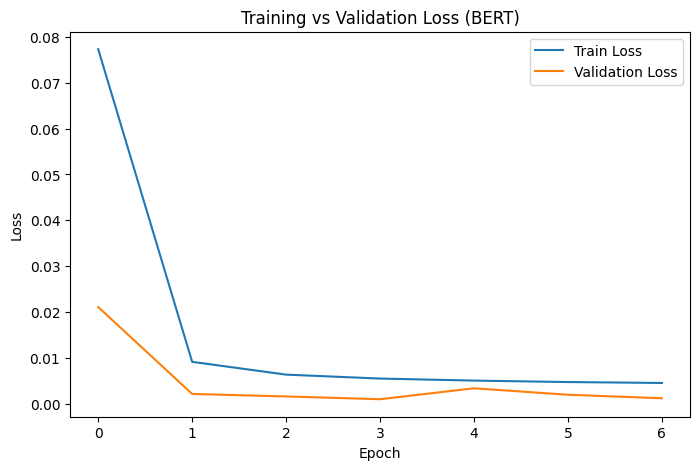

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (BERT)")
plt.legend()

plt.show()

In [22]:
model.load_state_dict(torch.load("bertbase_model.pt", map_location=DEVICE))
model.eval()

BertMultiHead(
  (encoder): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_

In [23]:
all_criteria = []
all_overall = []
all_true = []

with torch.no_grad():

    for ids, masks, crit, overall in test_loader:

        ids = ids.to(DEVICE)
        masks = masks.to(DEVICE)

        crit_pred, overall_pred = model(ids, masks)

        crit_pred = torch.clamp(crit_pred, 0, 1)
        overall_pred = torch.clamp(overall_pred, 0, 1)

        all_criteria.append(crit_pred.cpu().numpy())
        all_overall.append(overall_pred.cpu().numpy())
        all_true.append(overall.cpu().numpy())

all_criteria = np.vstack(all_criteria) * 9
overall_pred = np.concatenate(all_overall) * 9
overall_true = np.concatenate(all_true) * 9

In [24]:
vectorized_round = np.vectorize(round_band, otypes=[float])

In [25]:
print(overall_pred[:20])
print(vectorized_round(overall_pred)[:20])

[5.670412  3.9525807 6.325688  6.8688383 7.9638195 3.939499  3.8758717
 8.026501  3.9220147 7.5777926 5.167616  6.420372  7.792825  7.8525906
 8.619107  5.676121  7.992003  4.0118513 4.7198653 6.9656587]
[5.5 4.  6.5 7.  8.  4.  4.  8.  4.  7.5 5.  6.5 8.  8.  8.5 5.5 8.  4.
 4.5 7. ]


In [26]:
mae = mean_absolute_error(overall_true, overall_pred)
rmse = np.sqrt(mean_squared_error(overall_true, overall_pred))
pearson = pearsonr(overall_true, overall_pred)[0]

within_half = np.mean(np.abs(overall_pred - overall_true) <= 0.5)

true_band = np.round(overall_true * 2).astype(int)
pred_band = np.round(overall_pred * 2).astype(int)

qwk = cohen_kappa_score(true_band, pred_band, weights="quadratic")

print("\nTEST RESULTS")
print("MAE:", mae)
print("RMSE:", rmse)
print("Pearson:", pearson)
print("Within ±0.5:", within_half)
print("QWK:", qwk)


TEST RESULTS
MAE: 0.232716903090477
RMSE: 0.2980257244279862
Pearson: 0.99722236
Within ±0.5: 0.8674101610904585
QWK: 0.9795737572137289


In [27]:
criteria_mean = all_criteria.mean(axis=1)

print("\n===== CONSISTENCY CHECK =====")
print("MAE(mean(criteria), overall_true):",
      mean_absolute_error(overall_true, criteria_mean))

print("Pearson:",
      pearsonr(criteria_mean, overall_true)[0])


===== CONSISTENCY CHECK =====
MAE(mean(criteria), overall_true): 0.22957347333431244
Pearson: 0.9974334


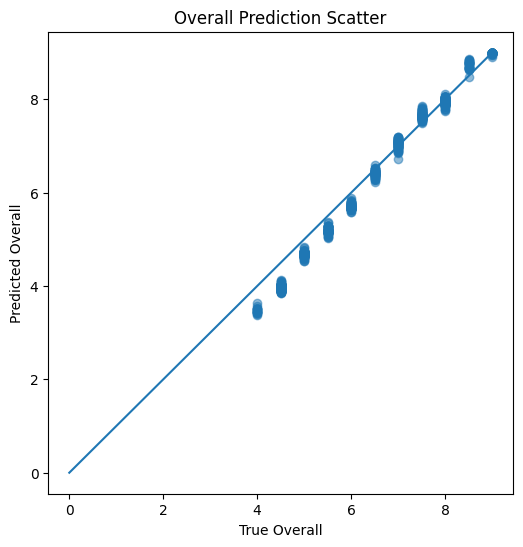

In [28]:
plt.figure(figsize=(6,6))
plt.scatter(overall_true, overall_pred, alpha=0.5)

# đường y = x (perfect prediction)
plt.plot([0, 9], [0, 9])

plt.xlabel("True Overall")
plt.ylabel("Predicted Overall")
plt.title("Overall Prediction Scatter")

plt.show()

In [29]:

test_df = df_full.iloc[test_idx].copy().reset_index(drop=True)

overall_pred_rounded = vectorized_round(overall_pred)
criteria_rounded = vectorized_round(all_criteria)

test_df["overall_pred_raw"] = overall_pred
test_df["overall_pred"] = overall_pred_rounded

test_df["Task_Achievement_pred"] = all_criteria[:, 0]
test_df["Coherence_Cohesion_pred"] = all_criteria[:, 1]
test_df["Lexical_Resource_pred"] = all_criteria[:, 2]
test_df["Range_Accuracy_pred"] = all_criteria[:, 3]

test_df["Task_Achievement_pred_round"] = criteria_rounded[:, 0]
test_df["Coherence_Cohesion_pred_round"] = criteria_rounded[:, 1]
test_df["Lexical_Resource_pred_round"] = criteria_rounded[:, 2]
test_df["Range_Accuracy_pred_round"] = criteria_rounded[:, 3]

test_df["error_raw"] = test_df["overall_pred_raw"] - test_df["Overall"]
test_df["error_round"] = test_df["overall_pred"] - test_df["Overall"]

test_df["criteria_mean"] = all_criteria.mean(axis=1)
test_df["criteria_std"] = np.std(all_criteria, axis=1)

test_df.head(10)

,Topic,Question,Essay,Task_Achievement,Coherence_Cohesion,Lexical_Resource,Range_Accuracy,Overall,Overall_Clean,Examiner_Comment,...,Coherence_Cohesion_pred,Lexical_Resource_pred,Range_Accuracy_pred,Task_Achievement_pred_round,Coherence_Cohesion_pred_round,Lexical_Resource_pred_round,Range_Accuracy_pred_round,error_raw,error_round,criteria_std
0,Table,Percentage of UK people who consumed daily rec...,Given is the chart comparing the ratio of the ...,6.5,5.5,5.5,5.5,6.0,6.0,**Task Achievement: [6.5]**\nThe report addres...,...,5.481671,5.428283,5.003513,6.5,5.5,5.5,5.0,-0.329588,-0.5,0.506027
1,Map,The maps below shows university sports courts ...,The provided map depicts the university sports...,5.0,4.0,4.0,4.0,4.5,4.5,**Task Achievement: [5]**\nThe main features o...,...,3.674669,3.971646,3.407014,5.0,3.5,4.0,3.5,-0.547419,-0.5,0.532691
2,Table,The table describes the number of employees an...,The presented table provides the sum of worker...,7.0,6.0,6.0,6.0,6.5,6.5,**Task Achievement: [7]**\nThe report provides...,...,6.192128,6.074259,5.869864,7.0,6.0,6.0,6.0,-0.174312,0.0,0.382731
3,Map,The two maps below show road access to a city ...,The maps illustrate the previous plan of road ...,7.5,7.5,6.5,6.5,7.0,7.0,**Task Achievement: [7.5]**\nThe report addres...,...,6.841682,6.742059,6.713248,7.0,7.0,6.5,6.5,-0.131162,0.0,0.144224
4,Pie Chart,The three pie charts below show the changes in...,The three given pie charts depict a UK school’...,8.5,8.0,8.0,8.0,8.0,8.0,**Task Achievement: [8.5]**\nThe report provid...,...,8.053770,7.780339,8.129375,8.0,8.0,8.0,8.0,-0.036180,0.0,0.135453
5,Line Graph,The graph below gives information about how te...,This line graph illustrates the percentage of ...,5.5,4.5,5.0,3.0,4.5,4.5,**Task Achievement: [5.5]**\nThe main features...,...,3.665307,3.930582,3.423837,5.0,3.5,4.0,3.5,-0.560501,-0.5,0.541533
6,Table,The table below shows the cinema viewing figur...,The table below illustrates the cinema watchin...,6.0,4.0,4.5,3.5,4.5,4.5,**Task Achievement: [6]**\nThe report provides...,...,3.673310,3.955793,3.401825,5.0,3.5,4.0,3.5,-0.624128,-0.5,0.578786
7,Bar Chart,The chart below gives some of the most reporte...,The provided bar graph illustrates the most re...,8.0,7.5,7.5,8.5,8.0,8.0,**Task Achievement: [8]**\nThe report provides...,...,8.231024,7.824307,8.277488,8.0,8.0,8.0,8.5,0.026501,0.0,0.186656
8,Process Diagram,The diagram below shows how rain water is coll...,The given diagram illustrates the how Austrial...,5.0,4.0,4.0,4.0,4.5,4.5,**Task Achievement: [5]**\nThe main features o...,...,3.704885,3.932998,3.348282,5.0,3.5,4.0,3.5,-0.577985,-0.5,0.545129
9,Pie Chart,The two charts below show the proportion of qu...,The pie charts below illustrated the percentag...,8.0,8.0,7.5,6.5,7.5,7.5,**Task Achievement: [8]**\nThe report provides...,...,7.650054,7.404216,7.662126,7.5,7.5,7.5,7.5,0.077793,0.0,0.108855


In [30]:
df_missing["input_text"] = (
    "Overall Score: " + df_missing["Overall"].astype(str) +
    " | Topic: " + df_missing["Topic"].astype(str) +
    " | Word count: " + df_missing["length"].astype(str) +
    " | Question: " + df_missing["Question"].astype(str) +
    " [SEP] Essay: " + df_missing["Essay"].astype(str)
)

encoded_missing = tokenizer(
    df_missing["input_text"].tolist(),
    padding=True,
    truncation=True,
    max_length=MAX_LENGTH,
    return_tensors="pt"
)

missing_ids = encoded_missing["input_ids"]
missing_masks = encoded_missing["attention_mask"]

model.eval()

all_criteria_missing = []
all_overall_missing = []

with torch.no_grad():

    for i in range(0, len(missing_ids), BATCH_SIZE):

        batch_ids = missing_ids[i:i+BATCH_SIZE].to(DEVICE)
        batch_masks = missing_masks[i:i+BATCH_SIZE].to(DEVICE)

        crit_pred, overall_pred = model(batch_ids, batch_masks)

        crit_pred = torch.clamp(crit_pred, 0, 1)
        overall_pred = torch.clamp(overall_pred, 0, 1)

        overall_batch = df_missing["Overall"].values[i:i+BATCH_SIZE] / 9.0
        overall_batch = torch.tensor(overall_batch, dtype=torch.float32).to(DEVICE)

        scale = overall_batch / (crit_pred.mean(dim=1) + 1e-6)
        crit_pred = crit_pred * scale.unsqueeze(1)

        all_criteria_missing.append(crit_pred.cpu().numpy())
        all_overall_missing.append(overall_pred.cpu().numpy())

all_criteria_missing = np.vstack(all_criteria_missing) * 9
overall_missing_pred = np.concatenate(all_overall_missing) * 9

In [31]:
criteria_missing_rounded = vectorized_round(all_criteria_missing)
overall_missing_rounded = vectorized_round(overall_missing_pred)

missing_df = df_missing.copy().reset_index(drop=True)

missing_df["overall_pred_raw"] = overall_missing_pred
missing_df["overall_pred"] = overall_missing_rounded

missing_df["Task_Achievement_pred"] = all_criteria_missing[:, 0]
missing_df["Coherence_Cohesion_pred"] = all_criteria_missing[:, 1]
missing_df["Lexical_Resource_pred"] = all_criteria_missing[:, 2]
missing_df["Range_Accuracy_pred"] = all_criteria_missing[:, 3]

missing_df["Task_Achievement_pred_round"] = criteria_missing_rounded[:, 0]
missing_df["Coherence_Cohesion_pred_round"] = criteria_missing_rounded[:, 1]
missing_df["Lexical_Resource_pred_round"] = criteria_missing_rounded[:, 2]
missing_df["Range_Accuracy_pred_round"] = criteria_missing_rounded[:, 3]

missing_df["criteria_mean"] = all_criteria_missing.mean(axis=1)
missing_df["criteria_std"] = np.std(all_criteria_missing, axis=1)

missing_df.head(10)

,Topic,Question,Essay,Task_Achievement,Coherence_Cohesion,Lexical_Resource,Range_Accuracy,Overall,Overall_Clean,Examiner_Comment,...,Task_Achievement_pred,Coherence_Cohesion_pred,Lexical_Resource_pred,Range_Accuracy_pred,Task_Achievement_pred_round,Coherence_Cohesion_pred_round,Lexical_Resource_pred_round,Range_Accuracy_pred_round,criteria_mean,criteria_std
0,Process Diagram,"Eating sweet foods produces acid in the mouth,...",The diagram illustrates a comparsion of differ...,NaN,NaN,NaN,NaN,5.0,5.0,NaN,...,5.952779,4.699351,4.831242,4.516588,6.0,4.5,5.0,4.5,4.999990,0.561325
1,Process Diagram,"Eating sweet foods produces acid in the mouth,...",The diagram illustrates the acid level in the ...,NaN,NaN,NaN,NaN,7.0,7.0,NaN,...,7.463422,6.943747,6.880760,6.712035,7.5,7.0,7.0,6.5,6.999991,0.280654
2,Line Graph,"Eating sweet foods produces acid in the mouth,...",The line graph depicts how a decay can appear ...,NaN,NaN,NaN,NaN,5.5,5.5,NaN,...,6.425156,5.340171,5.251153,4.983481,6.5,5.5,5.5,5.0,5.499990,0.550040
3,Table,Percentage of UK people who consumed daily rec...,The bar chart illustrates the rate of people w...,NaN,NaN,NaN,NaN,5.5,5.5,NaN,...,6.356218,5.348028,5.290270,5.005446,6.5,5.5,5.5,5.0,5.499990,0.511071
4,Table,Percentage of UK people who consumed daily rec...,The bar chart shed light on the proportions of...,NaN,NaN,NaN,NaN,7.5,7.5,NaN,...,7.672237,7.518214,7.262076,7.547435,7.5,7.5,7.5,7.5,7.499990,0.149043
5,Table,Percentage of UK people who consumed daily rec...,The bar graph compares the proportion of UK ci...,NaN,NaN,NaN,NaN,6.0,6.0,NaN,...,6.866207,5.898523,5.793948,5.441283,7.0,6.0,6.0,5.5,5.999990,0.528023
6,Table,Percentage of UK people who consumed daily rec...,The graph illustrates the percentage of fruit ...,NaN,NaN,NaN,NaN,5.5,5.5,NaN,...,6.345647,5.398831,5.272063,4.983421,6.5,5.5,5.5,5.0,5.499990,0.510922
7,Multiple Graphs,The Pie chart gives information about the coun...,The pie chart illustrates the percentage of Au...,NaN,NaN,NaN,NaN,6.5,6.5,NaN,...,7.120205,6.461896,6.394763,6.023101,7.0,6.5,6.5,6.0,6.499991,0.395163
8,Multiple Graphs,The Pie chart gives information about the coun...,The pie chart presents the information that th...,NaN,NaN,NaN,NaN,4.5,4.5,NaN,...,5.509649,4.156317,4.493817,3.840177,5.5,4.0,4.5,4.0,4.499990,0.627079
9,Multiple Graphs,The Pie chart gives information about the coun...,"There are many people lives in Australia,but t...",NaN,NaN,NaN,NaN,3.5,3.5,NaN,...,4.159981,3.386517,3.400849,3.052626,4.0,3.5,3.5,3.0,3.499993,0.405718


# Model

1. dung model bert cham diem -> so sanh voi ground true  

va fine tune ( co epocs )  voi pretrained model voi train on smaller ds, 
diem (test) -> so sanh voi lable ( tìm error)

2.  technique finetune: Lora va Qlora 

3. RAG dùng supported doccument -> bắt tiêu chí chấm điểm -> điểm so sánh với true label